# Native appended VTK XML reads

VTK's own writers produce these single-piece VTP/VTS/VTR/VTI files with **raw or base64 appended arrays**, zlib compression and UInt64 headers. meshio++ reads them natively, without falling back to Python. VTS points can be curved and VTR axes graded. The Python reference uses the same framing contract. Multiple pieces are also supported (see `29_vtk_pieces_and_legacy.ipynb`); these formats' meshio++ writers remain inline.

Rendering uses off-screen PyVista embedded in matplotlib, with a matplotlib-only fallback when GL is unavailable.

In [1]:
import importlib
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import vtk

import meshioplusplus as mio
from meshioplusplus import _core, _fallback

pv.OFF_SCREEN = True
tmp = tempfile.TemporaryDirectory()
directory = Path(tmp.name)
x, y, z = np.meshgrid(np.linspace(0, 2, 9), np.linspace(0, 1, 6), np.linspace(0, 1, 5), indexing='ij')
curved = pv.StructuredGrid(x, y, z + 0.15 * np.sin(np.pi * x) * y)
sources = {
    'vtp': curved.extract_surface(algorithm='dataset_surface').triangulate(),
    'vts': curved,
    'vtr': pv.RectilinearGrid(np.linspace(0, np.sqrt(2), 9)**2, np.linspace(0, 1, 6), np.linspace(0, 1, 5)),
    'vti': pv.ImageData(dimensions=(9, 6, 5), spacing=(0.25, 0.2, 0.25)),
}
writers = {'vtp': vtk.vtkXMLPolyDataWriter, 'vts': vtk.vtkXMLStructuredGridWriter, 'vtr': vtk.vtkXMLRectilinearGridWriter, 'vti': vtk.vtkXMLImageDataWriter}
results = {}
for fmt, source in sources.items():
    source.point_data['temperature'] = 20 + 10 * source.points[:, 0] + 5 * source.points[:, 2]
    for encoded in (False, True):
        path = directory / f'{fmt}_{encoded}.{fmt}'
        writer = writers[fmt]()
        writer.SetInputData(source)
        writer.SetFileName(str(path))
        writer.SetDataModeToAppended()
        writer.SetEncodeAppendedData(encoded)
        writer.SetHeaderTypeToUInt64()
        writer.SetCompressorTypeToZLib()
        assert writer.Write() == 1
        mesh = getattr(_core, fmt + '_read')(str(path))
        reference = importlib.import_module(f'meshioplusplus.{fmt}._{fmt}').read(path)
        np.testing.assert_array_equal(mesh.points, source.points)
        np.testing.assert_array_equal(mesh.point_data['temperature'], reference.point_data['temperature'])
        meta = _core.read_metadata(str(path), fmt)
        print(f'{fmt.upper():3} {"base64" if encoded else "raw":6}: {meta["num_points"]} points, {meta["num_cells"]} cells')
        results[fmt] = mesh
old_strict = _fallback._strict
try:
    _fallback._strict = True
    selected = mio.read(directory / 'vti_False.vti', arrays=['temperature'])
    geometry = mio.read(directory / 'vti_False.vti', points_only=True)
    assert not geometry.point_data and len(geometry.cells) == 1
finally:
    _fallback._strict = old_strict
print('Selective native reads retain connectivity; points_only suppresses data.')

VTP raw   : 258 points, 368 cells
VTP base64: 258 points, 368 cells
VTS raw   : 270 points, 160 cells
VTS base64: 270 points, 160 cells
VTR raw   : 270 points, 160 cells
VTR base64: 270 points, 160 cells
VTI raw   : 270 points, 160 cells
VTI base64: 270 points, 160 cells
Selective native reads retain connectivity; points_only suppresses data.


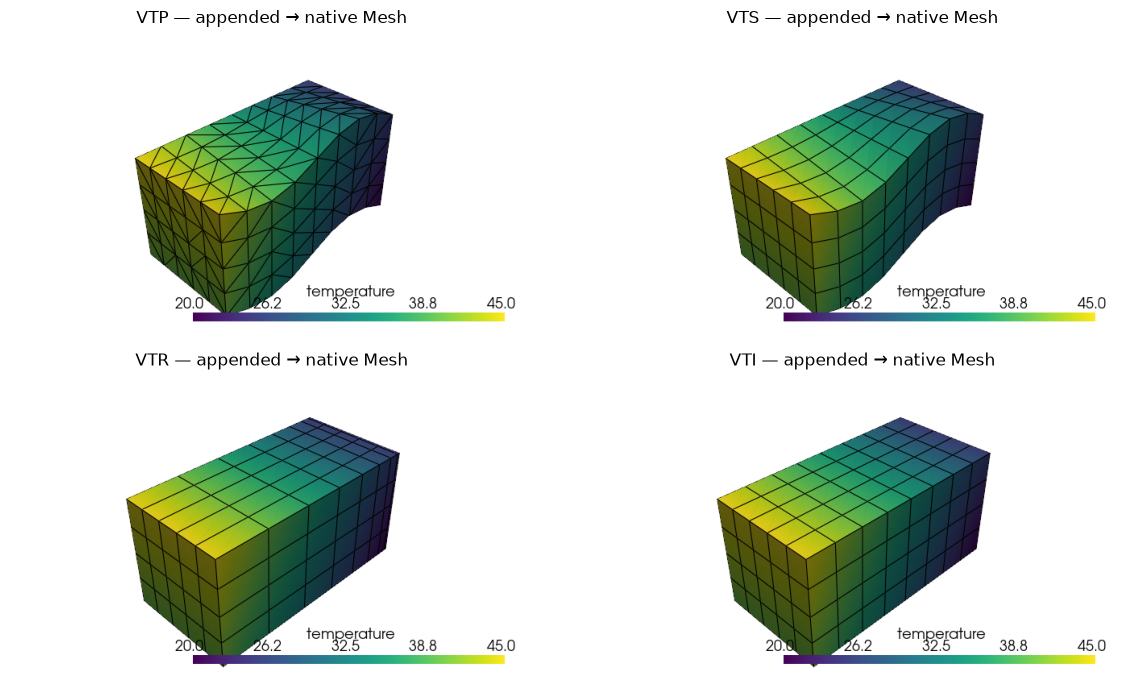

In [2]:
fig = plt.figure(figsize=(12, 7))
for index, (fmt, mesh) in enumerate(results.items(), 1):
    plotter = None
    try:
        plotter = pv.Plotter(off_screen=True, window_size=(650, 380))
        grid = mio.to_pyvista(mesh)
        plotter.add_mesh(grid, scalars='temperature', show_edges=True, clim=(20, 45), cmap='viridis')
        plotter.camera_position = 'iso'
        image = plotter.screenshot(return_img=True)
        ax = fig.add_subplot(2, 2, index)
        ax.imshow(image)
        ax.axis('off')
    except Exception as exc:
        print(f'{fmt}: matplotlib fallback ({type(exc).__name__})')
        ax = fig.add_subplot(2, 2, index, projection='3d')
        ax.scatter(*mesh.points.T, c=mesh.point_data['temperature'], s=12, vmin=20, vmax=45, cmap='viridis')
        ax.set_box_aspect((2, 1, 1))
    finally:
        if plotter is not None:
            plotter.close()
    ax.set_title(f'{fmt.upper()} — appended → native Mesh')
fig.tight_layout()
plt.show()
tmp.cleanup()